In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex
from trait_prediction.utils import (
    read_interpro_features,
    read_rast_features,
)

## Reading the data


In [3]:
data_folder = pathlib.Path("../data/raw/")

metabolic_phenotype_file = data_folder / "metabolic_phenotypes_bacdive.tsv"
non_metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
rast_feature_file = data_folder / "rast_features.tsv"
interpro_feature_file = data_folder / "interpro_features.tsv"

In [4]:
metabolic_phenotypeset = PhenotypeSet.read_data(str(metabolic_phenotype_file))
non_metabolic_phenotypeset = PhenotypeSet.read_data(str(non_metabolic_phenotype_file))

In [5]:
rast_features, rast_sso_dict = read_rast_features(rast_feature_file)
interpro_features, interpro_ipr_dict = read_interpro_features(interpro_feature_file)

In [6]:
glucose_index = PhenotypeIndex(name="glucose", category="carbon_source")
glucose_phenotype = metabolic_phenotypeset[glucose_index]
glucose_phenotype.set_feature_data(rast_features, "rast")

In [7]:
glucose_phenotype

Phenotype (name=glucose, category=carbon_source, size=1606)

## Machine learning using the RAST annotations


In [8]:
from collections import Counter

counter = Counter(glucose_phenotype.phenotype_data)
counter

Counter({1: 1582, 0: 24})

In [9]:
low_var_features, correlated_features_dict = glucose_phenotype.filter_feature_data(
    variance_threshold=0.05, correlation_treshold=0.95
)

In [10]:
from catboost import CatBoostClassifier

In [11]:
random_state = 42

In [12]:
categorical_feature_names = glucose_phenotype.feature_data.columns.tolist()

In [13]:
clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    random_state=random_state,
    loss_function="Logloss",
    cat_features=categorical_feature_names,
    verbose=False,
)

In [14]:
from trait_prediction.training import PhenotypePredictor

In [15]:
phenotype_predictor = PhenotypePredictor(
    glucose_phenotype, clf, random_state=random_state
)

In [16]:
data = phenotype_predictor.split_data(test_size=0.3, stratify=True, imbalanced="auto")

Performing Oversampling...


In [17]:
phenotype_predictor.fit()

In [18]:
y_pred = phenotype_predictor.predict()

In [19]:
y_true = data["y_test"]

In [20]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.99      1.00      0.99       475

    accuracy                           0.98       482
   macro avg       0.49      0.50      0.50       482
weighted avg       0.97      0.98      0.98       482



In [22]:
balanced_accuracy_score(y_true, y_pred)

0.4978947368421053

In [23]:
# FIXME: You cannot use cv when using oversampling!
phenotype_predictor._y_train.value_counts()

glucose--carbon_source
1    1107
0    1107
Name: count, dtype: int64

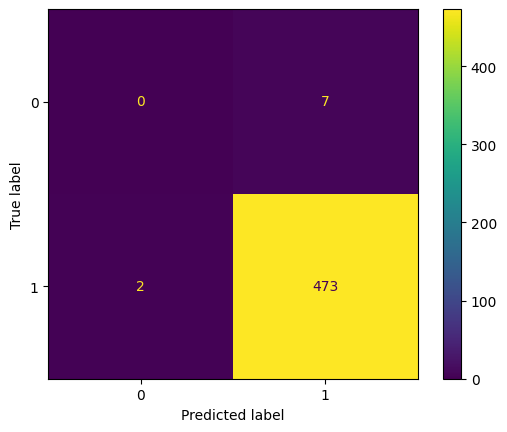

In [24]:
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()

In [25]:
cv_scores, estimators = phenotype_predictor.cross_validate_kfold(n_splits=5)

In [26]:
cv_scores

,metric,score,fold
0,balanced_accuracy,1.000000,1
1,balanced_accuracy,1.000000,2
2,balanced_accuracy,0.997738,3
3,balanced_accuracy,1.000000,4
4,balanced_accuracy,0.993213,5
5,precision,1.000000,1
6,precision,1.000000,2
7,precision,1.000000,3
8,precision,1.000000,4
9,precision,1.000000,5


<Axes: xlabel='score', ylabel='metric'>

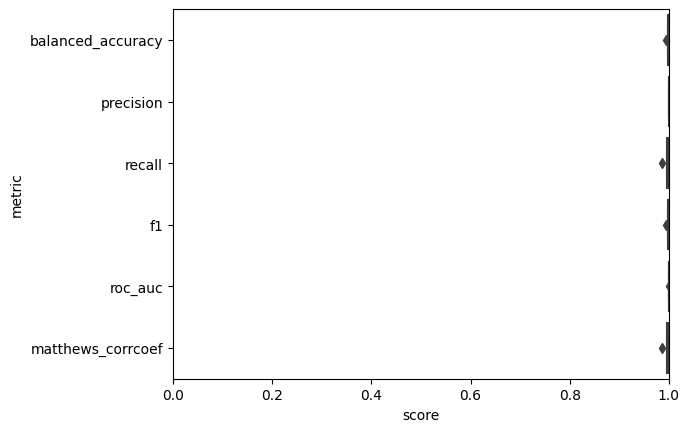

In [27]:
phenotype_predictor.plot_cross_validation(cv_scores)

## SHAP values


In [28]:
import shap

In [29]:
explainer = shap.Explainer(clf)

In [30]:
shap_values = explainer(glucose_phenotype.feature_data)

In [31]:
shap_values

.values =
array([[-2.40984562e-02,  0.00000000e+00,  0.00000000e+00, ...,
        -1.66716802e-03, -1.37735686e-02, -5.77219142e-06],
       [ 8.41047968e-02,  0.00000000e+00,  0.00000000e+00, ...,
        -3.64431402e-04,  8.14079382e-03, -5.77219142e-06],
       [-1.87244011e-02,  0.00000000e+00,  0.00000000e+00, ...,
         7.16056593e-04,  1.29831009e-03, -5.77219142e-06],
       ...,
       [-8.76701954e-03,  0.00000000e+00,  0.00000000e+00, ...,
         3.98038939e-04,  8.14079382e-03, -1.44837175e-07],
       [-7.49173411e-03,  0.00000000e+00,  0.00000000e+00, ...,
         3.98038939e-04,  8.14079382e-03, -1.44837175e-07],
       [-1.02604453e-02,  0.00000000e+00,  0.00000000e+00, ...,
         6.71877176e-05,  8.14079382e-03, -1.44837175e-07]])

.base_values =
array([0.1215246, 0.1215246, 0.1215246, ..., 0.1215246, 0.1215246,
       0.1215246])

.data =
array([[1, 0, 0, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 1, 1],
       ...,
       [1, 0, 

In [32]:
# shap.plots.waterfall(shap_values[0])

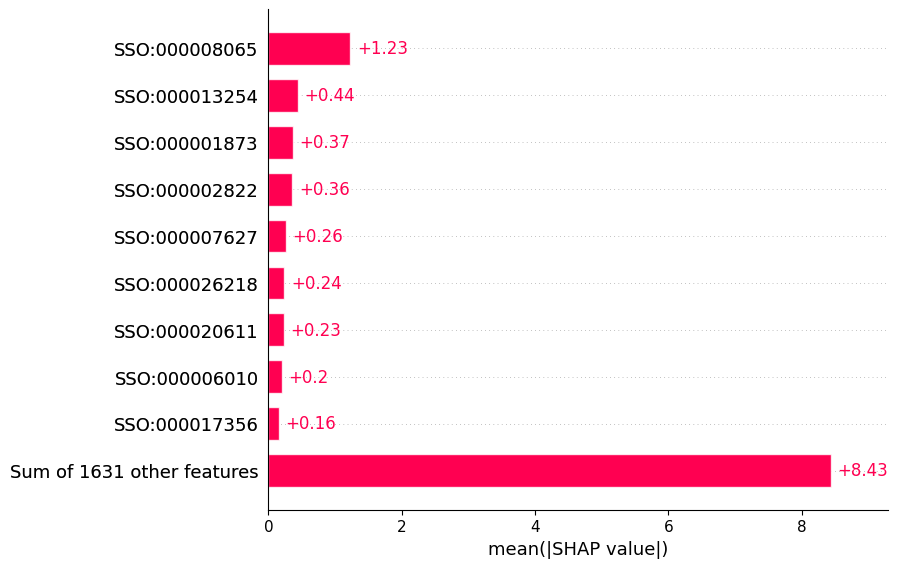

In [33]:
shap.plots.bar(shap_values)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


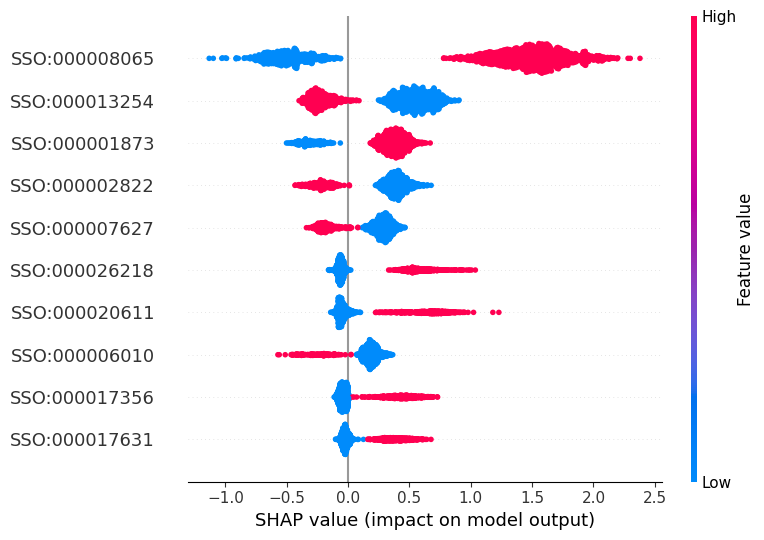

In [42]:
shap.summary_plot(shap_values, max_display=10)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


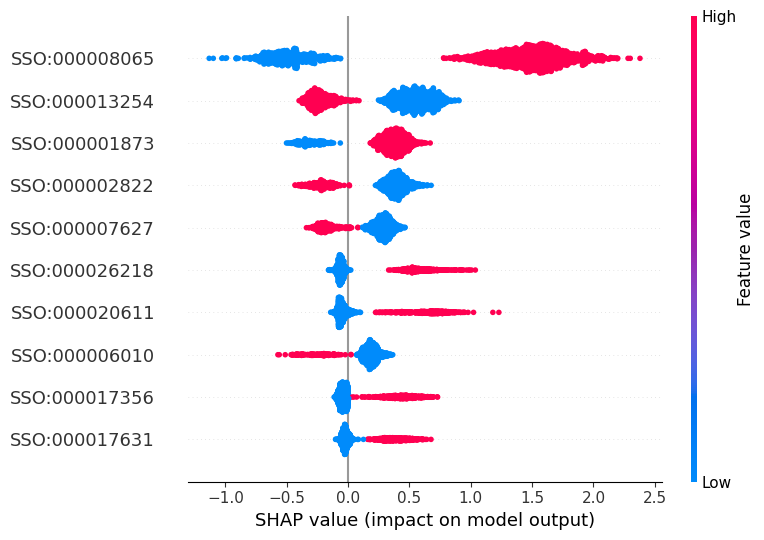

AttributeError: 'NoneType' object has no attribute 'savefig'

In [44]:
shap.summary_plot(shap_values, max_display=10)

In [35]:
rast_sso_dict["SSO:000008065"], rast_sso_dict["SSO:000013254"], rast_sso_dict[
    "SSO:000001873"
],

('Thymidine kinase (EC 2.7.1.21)',
 'DsrE family protein',
 'Cytidine deaminase (EC 3.5.4.5)')

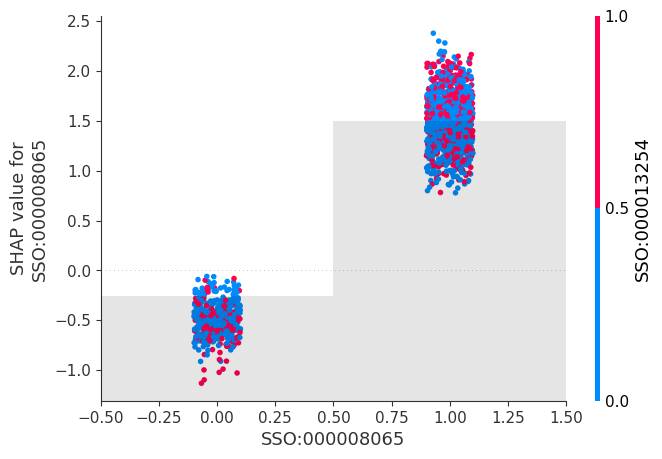

In [41]:
shap.plots.scatter(shap_values[:, "SSO:000008065"], color=shap_values[:, "SSO:000013254"])